# Résolution de F(x)=0

In [20]:
import sympy as sp
import scipy as sc
import numpy as np
from time import sleep,time

## Un exemple en dimension 1

On s'intéresse ici au calcul de la racine carré de $2$.
Pour cela, on va résoudre l'équation
$$ x^2-2 =0$$
c'est-à-dire que $F(x)=x^2-2$.

In [21]:
F = lambda x : x**2-2

- ### Application de la méthode du point fixe

On définit $G_\omega$. On va en fait gérer $\omega$ comme une variable, car on lui donnera différentes valeurs par la suite.

In [22]:
G = lambda x,omega : x + omega * F(x)

On sait qu'un bon choix est $\omega \simeq -1/F'(x^*)$, où $x^*=\sqrt{2}$ est une solution du problème, et $x^{(0)} \simeq x^*$.
On peut par exemple prendre $x^{(0)}=1.5$ et $\omega \simeq -1/F'(x^{(0)})$, mais on peut aussi fixer $\omega$ indépendamment du choix de $x^{(0)}$.

In [23]:
t = sp.symbols('t')
dF_dt = sp.diff(F(t),t)

x0 = 1.5
omega = -1/dF_dt.subs({t:x0})
eps = 1.e-9

## test |F(x)|<eps
x=x0
cpt=0
while abs(F(x)) > eps:
    x = G(x,omega)
    cpt+=1
print(f" x={x},\n erreur={abs(x-np.sqrt(2))},\n iterations={cpt}")

 x=1.41421356245763,
 erreur=8.45383762992924E-11,
 iterations=7


On change le test d'arrêt : on choisit ici de s'arrêter quand les itérés ne bougent plus suffisamment.

In [24]:
## test |x_courant - x_maj|<eps
x_courant=x0
cpt=0
d=1
while abs(d) > eps:
    x_maj = G(x_courant,omega)
    d=x_courant-x_maj
    x_courant = x_maj
    cpt+=1
print(f" x={x},\n erreur={abs(x-np.sqrt(2))},\n iterations={cpt}")

 x=1.41421356245763,
 erreur=8.45383762992924E-11,
 iterations=8


On fait les deux tests précédents de manière simultanée.

In [25]:
## test max(|F(x)|,|x_courant - x_maj|)<eps
x_courant=x0
cpt=0
d=1
while max(abs(F(x)),abs(d)) > eps:
    x_maj = G(x_courant,omega)
    d=x_courant-x_maj
    x_courant = x_maj
    cpt+=1
print(f" x={x},\n erreur={abs(x-np.sqrt(2))},\n iterations={cpt}")

 x=1.41421356245763,
 erreur=8.45383762992924E-11,
 iterations=8


Tester plusieurs valeurs pour $\omega$, $x^{(0)}$, la précision $\varepsilon$.

On trace d'abord la courbe du nombre d'itérations en fonction de la précision choisie, en échelle semi-logarithmique (en $x$).

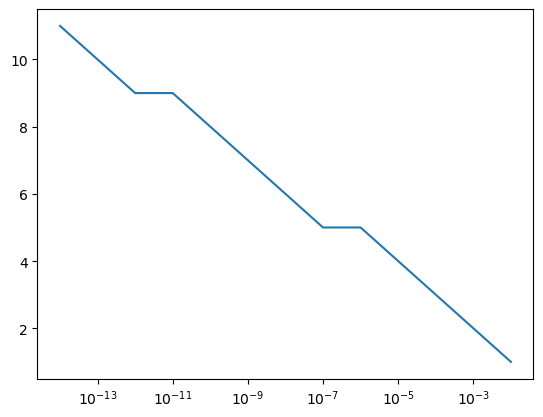

In [26]:
def pt_fixe(omega,x0,eps):
    x=x0
    cpt=0
    while abs(F(x)) > eps:
        x = G(x,omega)
        cpt+=1
    return [x,cpt]

precision=[10**(-k) for k in range(2,15)]
iterations=[]

for eps in precision:
    iterations.append(pt_fixe(omega,x0,eps)[1])

from matplotlib.pyplot import semilogx

semilogx(precision,iterations)

On trace maintenant la courbe de l'erreur (distance entre $x$ et la solution) en fonction du nombre d'itérations, en échelle semi-logarithmique (en $y$).

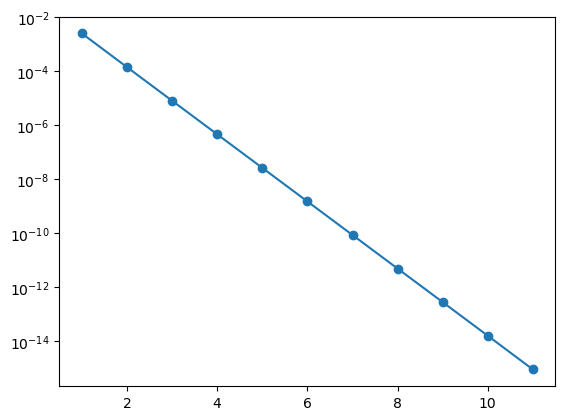

In [27]:
def pt_fixe(omega,x0,n):
    x=x0
    cpt=0
    for i in range(n):
        x = G(x,omega)
        cpt+=1
    return [x,abs(x-np.sqrt(2))]

erreur=[]
iterations=range(1,12)

for i in iterations:
    erreur.append(pt_fixe(omega,x0,i)[1])

from matplotlib.pyplot import semilogy

semilogy(iterations,erreur,'o-')

In [28]:
XMAX=10**3
def pt_fixe(omega,x0,eps):
    x=x0
    cpt=0
    while abs(F(x)) > eps and abs(x)<XMAX:
        x = G(x,omega)
        cpt+=1
    return [x,cpt]

tab_x0=[1.4,1.5,2.,1.,3.,10.]
tab_omega=[-1/dF_dt.subs({t:x}) for x in tab_x0]
tab_precision=[10**(-k) for k in range(2,12)]

for x0 in tab_x0:
    for omega in tab_omega:
        for eps in tab_precision:
            [x,cpt]=pt_fixe(omega,x0,eps)
            print(f" x0={x0}, omega={omega}, eps={eps},\n x={x},\t cpt={cpt}")

 x0=1.4, omega=-0.357142857142857, eps=0.01,
 x=1.41428571428571,	 cpt=1
 x0=1.4, omega=-0.357142857142857, eps=0.001,
 x=1.41428571428571,	 cpt=1
 x0=1.4, omega=-0.357142857142857, eps=0.0001,
 x=1.41421282798834,	 cpt=2
 x0=1.4, omega=-0.357142857142857, eps=1e-05,
 x=1.41421282798834,	 cpt=2
 x0=1.4, omega=-0.357142857142857, eps=1e-06,
 x=1.41421356982878,	 cpt=3
 x0=1.4, omega=-0.357142857142857, eps=1e-07,
 x=1.41421356982878,	 cpt=3
 x0=1.4, omega=-0.357142857142857, eps=1e-08,
 x=1.41421356229740,	 cpt=4
 x0=1.4, omega=-0.357142857142857, eps=1e-09,
 x=1.41421356229740,	 cpt=4
 x0=1.4, omega=-0.357142857142857, eps=1e-10,
 x=1.41421356237386,	 cpt=5
 x0=1.4, omega=-0.357142857142857, eps=1e-11,
 x=1.41421356237386,	 cpt=5
 x0=1.4, omega=-0.333333333333333, eps=0.01,
 x=1.41333333333333,	 cpt=1
 x0=1.4, omega=-0.333333333333333, eps=0.001,
 x=1.41416296296296,	 cpt=2
 x0=1.4, omega=-0.333333333333333, eps=0.0001,
 x=1.41421066769090,	 cpt=3
 x0=1.4, omega=-0.333333333333333, eps

 x0=2.0, omega=-0.500000000000000, eps=1e-11,
 x=1.41421356237485,	 cpt=30
 x0=2.0, omega=-0.166666666666667, eps=0.01,
 x=1.41668870910751,	 cpt=8
 x0=2.0, omega=-0.166666666666667, eps=0.001,
 x=1.41440650670343,	 cpt=12
 x0=2.0, omega=-0.166666666666667, eps=0.0001,
 x=1.41424205644965,	 cpt=15
 x0=2.0, omega=-0.166666666666667, eps=1e-05,
 x=1.41421578691573,	 cpt=19
 x0=2.0, omega=-0.166666666666667, eps=1e-06,
 x=1.41421389092994,	 cpt=22
 x0=2.0, omega=-0.166666666666667, eps=1e-07,
 x=1.41421358802409,	 cpt=26
 x0=2.0, omega=-0.166666666666667, eps=1e-08,
 x=1.41421356437571,	 cpt=30
 x0=2.0, omega=-0.166666666666667, eps=1e-09,
 x=1.41421356266887,	 cpt=33
 x0=2.0, omega=-0.166666666666667, eps=1e-10,
 x=1.41421356239619,	 cpt=37
 x0=2.0, omega=-0.166666666666667, eps=1e-11,
 x=1.41421356237651,	 cpt=40
 x0=2.0, omega=-0.0500000000000000, eps=0.01,
 x=1.41728751674617,	 cpt=33
 x0=2.0, omega=-0.0500000000000000, eps=0.001,
 x=1.41452538308576,	 cpt=48
 x0=2.0, omega=-0.0500000

 x0=3.0, omega=-0.0500000000000000, eps=0.01,
 x=1.41756134164241,	 cpt=37
 x0=3.0, omega=-0.0500000000000000, eps=0.001,
 x=1.41455312540602,	 cpt=52
 x0=3.0, omega=-0.0500000000000000, eps=0.0001,
 x=1.41424804235840,	 cpt=67
 x0=3.0, omega=-0.0500000000000000, eps=1e-05,
 x=1.41421706394264,	 cpt=82
 x0=3.0, omega=-0.0500000000000000, eps=1e-06,
 x=1.41421386768483,	 cpt=98
 x0=3.0, omega=-0.0500000000000000, eps=1e-07,
 x=1.41421359337902,	 cpt=113
 x0=3.0, omega=-0.0500000000000000, eps=1e-08,
 x=1.41421356552190,	 cpt=128
 x0=3.0, omega=-0.0500000000000000, eps=1e-09,
 x=1.41421356269287,	 cpt=143
 x0=3.0, omega=-0.0500000000000000, eps=1e-10,
 x=1.41421356240557,	 cpt=158
 x0=3.0, omega=-0.0500000000000000, eps=1e-11,
 x=1.41421356237639,	 cpt=173
 x0=10.0, omega=-0.357142857142857, eps=0.01,
 x=-22124.0178571429,	 cpt=3
 x0=10.0, omega=-0.357142857142857, eps=0.001,
 x=-22124.0178571429,	 cpt=3
 x0=10.0, omega=-0.357142857142857, eps=0.0001,
 x=-22124.0178571429,	 cpt=3
 x0=10.

- ### Application de la méthode de Newton

Dans un premier temps, reprendre la démarche précédente, en testant cette fois-ci en fonction du point de départ $x^{(0)}$ et de la précision choisie.

In [29]:
x0 = 1.5
eps = 1.e-14

## test |F(x)|<eps
x=x0
cpt=0
while abs(F(x)) > eps:
    x = x-F(x)/dF_dt.subs({t:x})
    cpt+=1
print(f" x={x},\n erreur={abs(x-np.sqrt(2))},\n iterations={cpt}")

 x=1.41421356237310,
 erreur=0,
 iterations=4


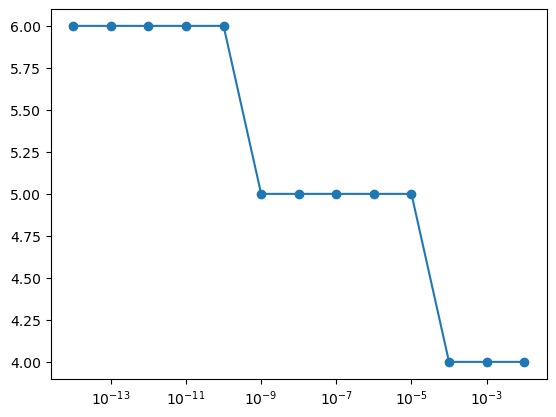

In [30]:
def newton(x0,eps):
    x=x0
    cpt=0
    while abs(F(x)) > eps:
        x = x-F(x)/dF_dt.subs({t:x})
        cpt+=1
    return [x,cpt]

precision=[10**(-k) for k in range(2,15)]
iterations=[]

x0=4
for eps in precision:
    iterations.append(newton(x0,eps)[1])

from matplotlib.pyplot import semilogx

semilogx(precision,iterations,'o-')

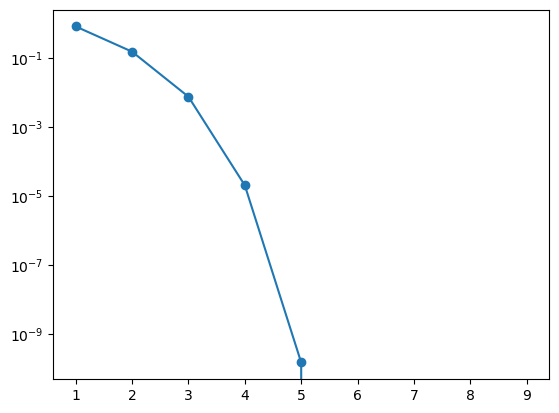

In [31]:
def newton(x0,n):
    x=x0
    cpt=0
    for i in range(n):
        x = x-F(x)/dF_dt.subs({t:x})
        cpt+=1
    return [x,abs(x-np.sqrt(2))]

erreur=[]
iterations=range(1,10)

x0=4
for i in iterations:
    erreur.append(newton(x0,i)[1])

from matplotlib.pyplot import semilogy

semilogy(iterations,erreur,'o-')

Dans un deuxième temps, on utilise, plutôt que la dérivée exacte de $F$, la formule des différences finies :
$$ F'(x) \simeq \frac{F(x+\delta)-F(x-\delta)}{2\delta} $$
où $\delta$ est choisi "petit". En général on impose que $\delta < 0.01 \varepsilon$, où $\varepsilon$ est la précision recherchée. Comparer les résultats.

## Un exemple en dimension 3

On s'intéresse ici au calcul d'un vecteur $(x,y,z)$ solution de $F(x,y,z)=(0,0,0)$ où

$$
F(x,y,z) = \begin{pmatrix}
\frac{-89.5 x - \sqrt{\lvert x \rvert +1} -10 y + 14 z +1}{54.5} \\
\frac{-10 x - 80.5 y - \frac{1}{2}\sin(y) + 4z}{54.5} \\
\frac{14 x + 4y - 92.5 z - \arctan(z/2)}{54.5} \\
\end{pmatrix}
$$

In [52]:
def F(X):
    a,b,c=X
    t1=-89.5*a-sp.sqrt(abs(a)+1)-10*b+14*c+1
    #t1=-35*a-sqrt(abs(a)+1)-10*b+14*a+1 ## erreur qui donne Xu meilleur ! 
    t2=-10*a-80.5*b-sp.sin(b)/2+4*c
    t3=14*a+4*b-92.5*c-sp.atan(c/2)
    return sp.Matrix([[t1,t2,t3]]).T/54.5

print('F(1,1,1)=',F(sp.Matrix([1.,1.,1.])))

F(1,1,1)= Matrix([[-1.57640758830042], [-1.59487588059457], [-1.37547977264222]])


On calcule la matrice jacobienne de $F$.

In [53]:
x,y,z = sp.symbols('x y z', real=True)
dF_dx = sp.diff(F([x,y,z]),x)
dF_dy = sp.diff(F([x,y,z]),y)
dF_dz = sp.diff(F([x,y,z]),z)
JF = sp.Matrix([dF_dx.T,dF_dy.T,dF_dz.T])
JF

Matrix([
[-1.64220183486239 - 0.00917431192660551*sign(x)/sqrt(Abs(x) + 1),                              -0.18348623853211,                                    0.256880733944954],
[                                               -0.18348623853211, -0.00917431192660551*cos(y) - 1.47706422018349,                                    0.073394495412844],
[                                               0.256880733944954,                              0.073394495412844, -1.69724770642202 - 0.00917431192660551/(z**2/4 + 1)]])

In [54]:
JF.subs({x:0.,y:1.,z:2.}).inv()

Matrix([
[ -0.631581173337997,  0.0736309323592991, -0.0921575492969785],
[ 0.0736309323592991,  -0.684782456269264, -0.0184182940382412],
[-0.0921575492969785, -0.0184182940382412,  -0.602305971604428]])

In [55]:
display(F([1.,2.,3.]))
print(f"norme(F([1.,2.,3.]))={F([1.,2.,3.]).norm()}")

Matrix([
[-1.24613235894263],
[-2.92577337088831],
[-4.70610630684858]])

norme(F([1.,2.,3.]))=5.67982677950331


In [56]:
J=JF.subs({x:0.,y:1.,z:2.})
OMEGA=J.inv()
a=sp.Matrix([1.,2.,3.])
b=J*a
display(a)
display(b)
display(OMEGA*b)
display(sp.Matrix([1.,2.,3.]))
display(sp.Matrix([1.,2.,3.]).T)

Matrix([
[1.0],
[2.0],
[3.0]])

Matrix([
[-1.23853211009174],
[-2.92734499643795],
[-4.70183486238532]])

Matrix([
[1.0],
[2.0],
[3.0]])

Matrix([
[1.0],
[2.0],
[3.0]])

Matrix([[1.0, 2.0, 3.0]])

Comme on n'a aucun idée de la solution, on partira de $x^{(0)}=(0,0,0)$ ou de $x^{(0)}=(0.5,0.5,0.5)$.

In [61]:
G = lambda xx,omega : xx + omega * F(xx)

xx0 = sp.Matrix([.5,.5,.5])
omega = -JF.subs({x:xx0[0],y:xx0[1],z:xx0[2]}).inv()
eps = 1.e-9

## test |F(x)|<eps
xx=xx0
cpt=0
while F(xx).norm() > eps:
    xx = G(xx,omega)
    cpt+=1
print(f" x={xx},\n iterations={cpt}")
display(xx)

 x=Matrix([[-2.61031448656638e-10], [2.84851737117232e-11], [-3.69572713403563e-11]]),
 iterations=4


Matrix([
[-2.61031448656638e-10],
[ 2.84851737117232e-11],
[-3.69572713403563e-11]])

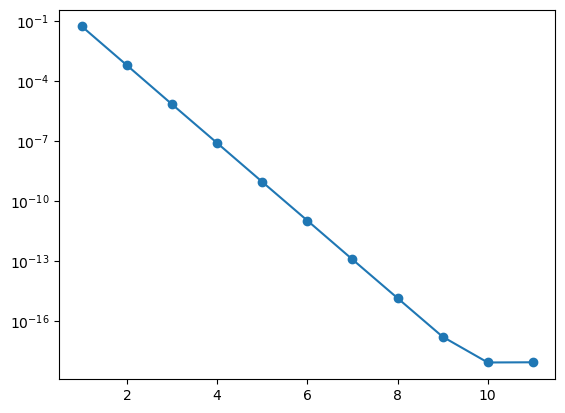

In [70]:
def pt_fixe(omega,xx0,n):
    xx=xx0
    cpt=0
    while cpt<n:
        xx = G(xx,omega)
        cpt+=1
    return [xx,xx.norm()]

xx0 = sp.Matrix([10.,10.,10.])
omega = -JF.subs({x:xx0[0],y:xx0[1],z:xx0[2]}).inv()

erreur=[]
iterations=range(1,12)

for i in iterations:
    erreur.append(pt_fixe(omega,xx0,i)[1])

from matplotlib.pyplot import semilogy

semilogy(iterations,erreur,'o-')

- ### Application de la méthode du point fixe

Pour la matrice $\omega$, on pourra prendre par exemple $\omega = - DF(x^{(0)})^{-1}$, où $DF(x^{(0)})$ est la Jacobienne de F au point $x^0$.

- ### Application de la méthode de Newton

Pour le calcul de $y=DF(X)^{-1}.F(X)$, on utilise la fonction de résolution de système linéaire LUsolve(), car ce vecteur $y$ est en fait solution du système $DF(X).y=F(X)$. Ainsi $y$ est donné par
$$
y \;\leftarrow\; \text{DF(X).LUsolve(F(X))}
$$

In [79]:
xx0 = sp.Matrix([10.5,-10.5,10.5])
omega = -JF.subs({x:xx0[0],y:xx0[1],z:xx0[2]}).inv()
eps = 1.e-14

## test |F(x)|<eps
xx=xx0
cpt=0
while F(xx).norm() > eps:
    yy = JF.subs({x:xx[0],y:xx[1],z:xx[2]}).LUsolve(F(xx))
    xx = xx-yy
    cpt+=1
print(f" x={xx},\n iterations={cpt}")
display(xx)


 x=Matrix([[-1.31497206380020e-16], [1.52891605920800e-17], [-1.91376837392514e-17]]),
 iterations=3


Matrix([
[ -1.3149720638002e-16],
[   1.528916059208e-17],
[-1.91376837392514e-17]])

## Inversion de matrice par la méthode de Newton

Soit $A$ une matrice inversible $d \times d$, alors la méthode de Newton appliquée au calcul d'une solution de l'équation
$$ X^{-1} -A = 0$$
est donnée par la récurrence
$$
\forall n \geq 0, \quad X^{n+1} = X^n (2\,I_d - A\,X^n) 
$$
où $I_d$ est la matrice de dimension $d$
<i>(attention aux notations : ici $X^{-1}$ est l'inverse de la matrice $X$, et dans la suite du paragraphe la notation $X^n$ désigne le $n$-ième terme de la suite générée par la méthode de Newton, pour $n \geq 0$)</i>.
En effet, si on définit $F : X \mapsto  X^{-1} -A$ alors on peut montrer que
$$ DF(X).H = - X^{-1} H X^{-1} $$
pour toute matrice $H$ de dimensiosn $d \times d$.
On en déduit
$$ DF(X)^{-1}.H = - X H X$$
On remarque que la méthode de Newton ne nécessite pas de calculer l'inverse !

In [74]:
A = 1.*sp.Matrix([[1,2,3],[3,2,1],[1,1,2]])
display(A)
A.det() # déterminant de A

Matrix([
[1, 2, 3],
[3, 2, 1],
[1, 1, 2]])

-4

Comme le point initial pour Newton doit être proche de la solution, on choisira une perturbation aléatoire de la solution, calculée à partir des deux matrices suivantes.

In [13]:
from numpy.random import rand

B=A.inv()
R=sp.Matrix(rand(3,3))

Comme critère d'arrêt, on choisit $\lVert XA - I_d \rVert < \varepsilon$, ce qui mesure le fait que $X$ est bien l'inverse de $A$.